# Assignment 9

## Imports

In [1]:
import random
from typing import List, Tuple, Optional
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

---
## Task 1 [3pkt]

1. Download the dataset from the following link:  
   https://www.kaggle.com/datasets/humansintheloop/semantic-segmentation-of-aerial-imagery  
2. Take a first look at the data. Are the classes balanced? Visualize a few interesting examples to better understand the dataset.  
3. Build a UNet model in PyTorch. You can use standard layers like `nn.Conv2d`, `nn.MaxPool2d`, and `nn.ConvTranspose2d`. Use Cross Entropy (`nn.CrossEntropyLoss`) as your loss function. Then train the model using the downloaded dataset.  
4. After training, visualize some filters from the convolutional layers. Do they seem to detect useful patterns or features?  
5. Evaluate the results. Does the model perform better on certain classes? Are there classes that are harder to predict?

In [1]:
!kaggle datasets download -d humansintheloop/semantic-segmentation-of-aerial-imagery
!unzip semantic-segmentation-of-aerial-imagery.zip -d dataset/

Dataset URL: https://www.kaggle.com/datasets/humansintheloop/semantic-segmentation-of-aerial-imagery
License(s): CC0-1.0
 91%|██████████████████████████████████▋   | 27.0M/29.6M [00:01<00:00, 24.9MB/s]
100%|██████████████████████████████████████| 29.6M/29.6M [00:01<00:00, 18.1MB/s]
Archive:  semantic-segmentation-of-aerial-imagery.zip
  inflating: dataset/Semantic segmentation dataset/Tile 1/images/image_part_001.jpg  
  inflating: dataset/Semantic segmentation dataset/Tile 1/images/image_part_002.jpg  
  inflating: dataset/Semantic segmentation dataset/Tile 1/images/image_part_003.jpg  
  inflating: dataset/Semantic segmentation dataset/Tile 1/images/image_part_004.jpg  
  inflating: dataset/Semantic segmentation dataset/Tile 1/images/image_part_005.jpg  
  inflating: dataset/Semantic segmentation dataset/Tile 1/images/image_part_006.jpg  
  inflating: dataset/Semantic segmentation dataset/Tile 1/images/image_part_007.jpg  
  inflating: dataset/Semantic segmentation dataset/Tile 1/ima

In [6]:
DATASET_ROOT = Path("dataset/Semantic segmentation dataset")

# Colors dont match with classes.json xd
PALETTE = {
    (60,  16,  152): 0,  # Building
    (132, 41,  246): 1,  # Land (unpaved area)
    (110, 193, 228): 2,  # Road
    (254, 221,  58): 3,  # Vegetation
    (226, 169,  41): 4,  # Water
    (155, 155, 155): 5,  # Unlabeled
}

CLASSES = {
    0: "Building",
    1: "Land (unpaved area)",
    2: "Road",
    3: "Vegetation",
    4: "Water",
    5: "Unlabeled",
}

NUM_CLASSES = len(CLASSES)
print("Palette:")
for rgb, idx in PALETTE.items():
    print(f"  {idx}: {CLASSES[idx]} RGB{rgb}")


Palette:
  0: Building RGB(60, 16, 152)
  1: Land (unpaved area) RGB(132, 41, 246)
  2: Road RGB(110, 193, 228)
  3: Vegetation RGB(254, 221, 58)
  4: Water RGB(226, 169, 41)
  5: Unlabeled RGB(155, 155, 155)


### 1.2 Class Balance & Visualization

In [12]:
def rgb_mask_to_class(mask_rgb: np.ndarray) -> np.ndarray:
    h, w, _ = mask_rgb.shape
    class_mask = np.zeros((h, w), dtype=np.uint8)
    for rgb, cls_idx in PALETTE.items():
        match = np.all(mask_rgb == np.array(rgb), axis=-1)
        class_mask[match] = cls_idx
    return class_mask


def collect_image_mask_pairs(root: Path):
    pairs = []
    for img_path in sorted(root.rglob("images/*.jpg")):
        mask_path = img_path.parent.parent / "masks" / (img_path.stem + ".png")
        if mask_path.exists():
            pairs.append((img_path, mask_path))
    return pairs


pairs = collect_image_mask_pairs(DATASET_ROOT)
print(f"Found {len(pairs)} image-mask pairs")

Found 72 image-mask pairs


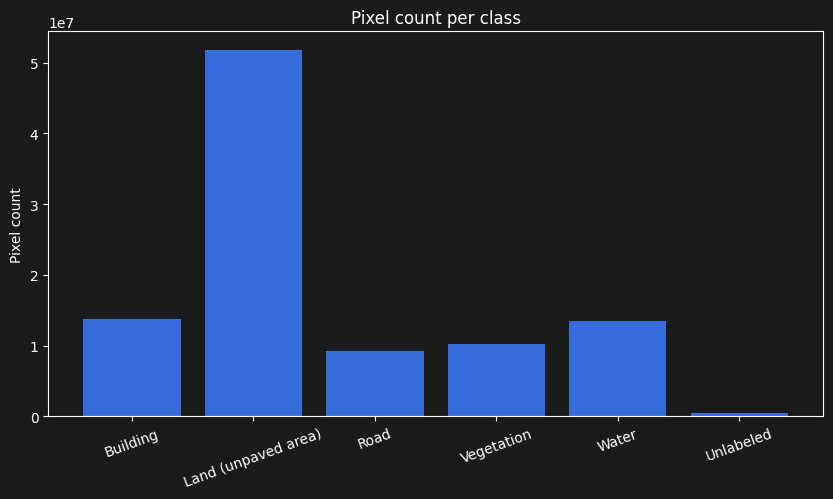

Building: 13,729,702 pixels (13.9%)
Land (unpaved area): 51,850,363 pixels (52.4%)
Road: 9,261,912 pixels (9.4%)
Vegetation: 10,206,379 pixels (10.3%)
Water: 13,482,196 pixels (13.6%)
Unlabeled: 501,691 pixels (0.5%)


In [13]:
class_counts = Counter()
for _, mask_path in pairs:
    mask_rgb = np.array(Image.open(mask_path).convert("RGB"))
    class_mask = rgb_mask_to_class(mask_rgb)
    class_counts.update(Counter(class_mask.flatten().tolist()))

labels = [CLASSES[i] for i in range(NUM_CLASSES)]
counts = [class_counts.get(i, 0) for i in range(NUM_CLASSES)]

plt.figure(figsize=(10, 5))
plt.bar(labels, counts)
plt.title("Pixel count per class")
plt.ylabel("Pixel count")
plt.xticks(rotation=20)
plt.show()

total = sum(counts)
for cls, cnt in zip(labels, counts):
    print(f"{cls}: {cnt:,} pixels ({100*cnt/total:.1f}%)")

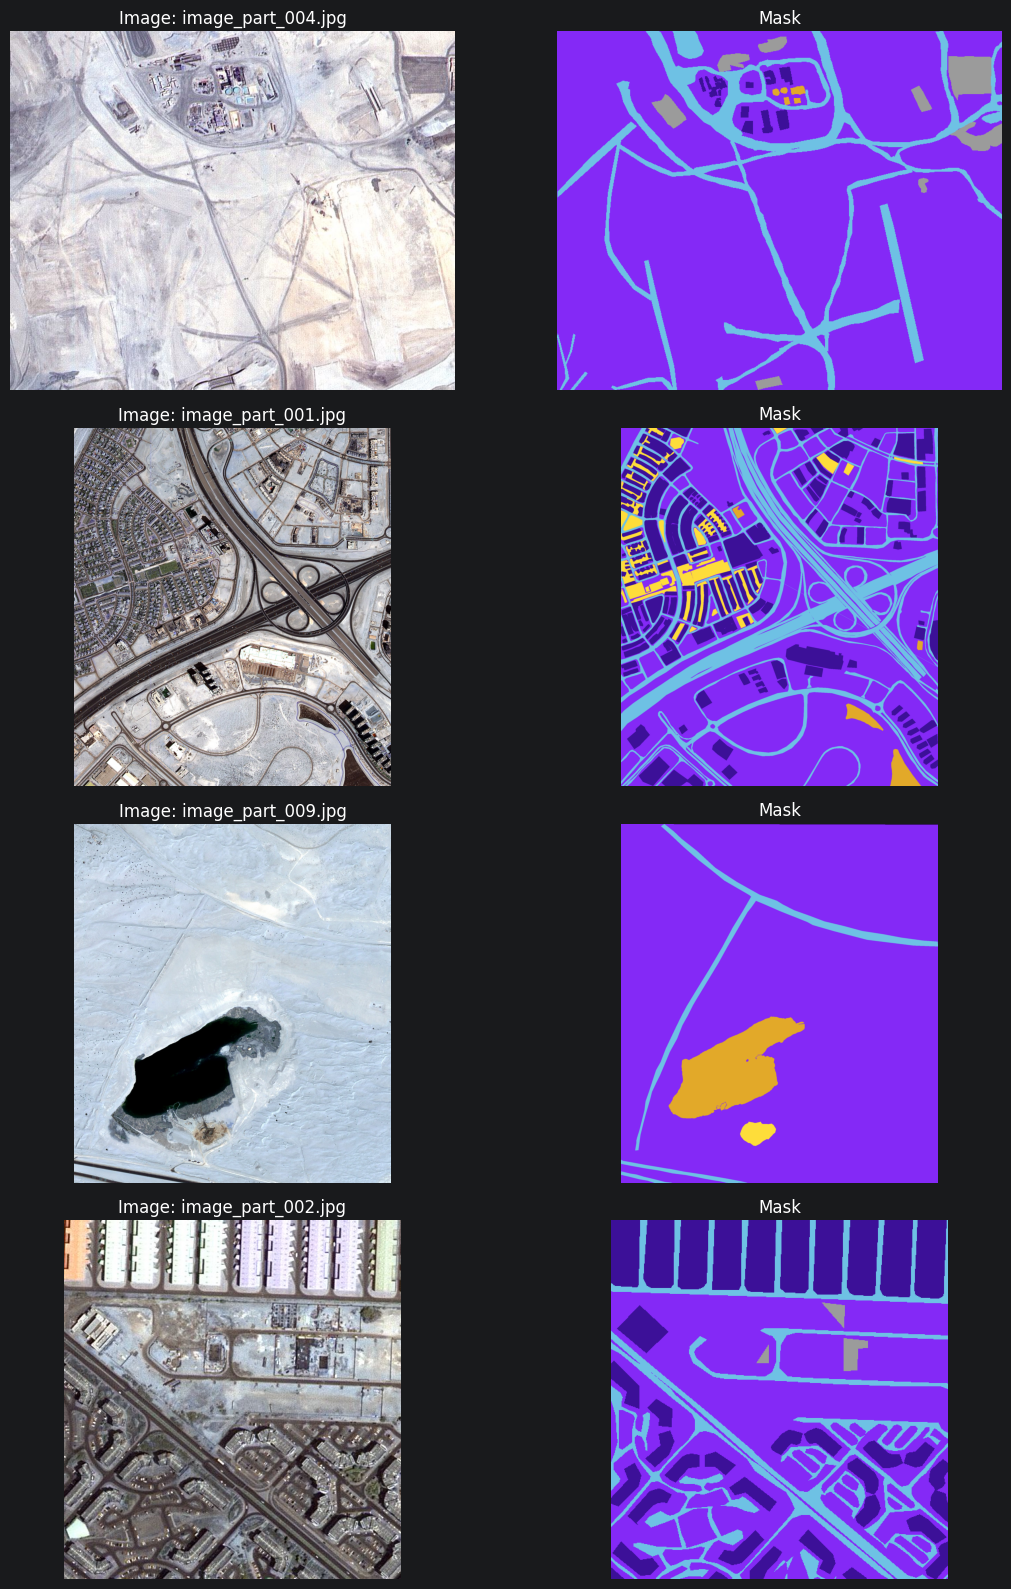

In [14]:
sample_pairs = random.sample(pairs, 4)

fig, axes = plt.subplots(len(sample_pairs), 2, figsize=(12, 4 * len(sample_pairs)))
for row, (img_path, mask_path) in enumerate(sample_pairs):
    img = np.array(Image.open(img_path).convert("RGB"))
    mask_rgb = np.array(Image.open(mask_path).convert("RGB"))
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"Image: {img_path.name}")
    axes[row, 0].axis("off")
    axes[row, 1].imshow(mask_rgb)
    axes[row, 1].set_title("Mask")
    axes[row, 1].axis("off")
plt.tight_layout()
plt.show()

**Are the classes balanced?**

No, classes are not balanced

### 1.3 Dataset & DataLoader

In [15]:
class AerialDataset(Dataset):
    def __init__(self, pairs, img_size=256, augment=False):
        self.pairs = pairs
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        img = Image.open(img_path).convert("RGB").resize((self.img_size, self.img_size))
        mask_rgb = np.array(Image.open(mask_path).convert("RGB").resize(
            (self.img_size, self.img_size), Image.NEAREST))
        mask = rgb_mask_to_class(mask_rgb)

        if self.augment and random.random() > 0.5:
            img = TF.hflip(img)
            mask = np.fliplr(mask).copy()

        img_tensor = transforms.ToTensor()(img)  # [3, H, W]
        mask_tensor = torch.from_numpy(mask).long()  # [H, W]
        return img_tensor, mask_tensor

In [16]:
random.shuffle(pairs)
split = int(0.8 * len(pairs))
train_pairs, val_pairs = pairs[:split], pairs[split:]

train_ds = AerialDataset(train_pairs, augment=True)
val_ds = AerialDataset(val_pairs, augment=False)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=2)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")

Train: 57, Val: 15


### 1.4 UNet Model

In [17]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=6, features=(64, 128, 256, 512)):
        super().__init__()
        self.encoders = nn.ModuleList()
        self.pools = nn.ModuleList()
        self.decoders = nn.ModuleList()
        self.upconvs = nn.ModuleList()

        # Encoder
        ch = in_channels
        for f in features:
            self.encoders.append(DoubleConv(ch, f))
            self.pools.append(nn.MaxPool2d(2))
            ch = f

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # Decoder
        for f in reversed(features):
            self.upconvs.append(nn.ConvTranspose2d(f * 2, f, 2, stride=2))
            self.decoders.append(DoubleConv(f * 2, f))

        self.final = nn.Conv2d(features[0], num_classes, 1)

    def forward(self, x):
        skip_connections = []
        for enc, pool in zip(self.encoders, self.pools):
            x = enc(x)
            skip_connections.append(x)
            x = pool(x)

        x = self.bottleneck(x)

        for up, dec, skip in zip(self.upconvs, self.decoders, reversed(skip_connections)):
            x = up(x)
            if x.shape != skip.shape:
                x = TF.resize(x, skip.shape[2:])
            x = torch.cat([skip, x], dim=1)
            x = dec(x)

        return self.final(x)


model = UNet(in_channels=3, num_classes=NUM_CLASSES).to(DEVICE)
print(f"Device: {DEVICE}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Device: cuda
Parameters: 31,043,846


### 1.5 Training

In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

NUM_EPOCHS = 20
train_losses, val_losses = [], []

for epoch in range(1, NUM_EPOCHS + 1):
    # --- Train ---
    model.train()
    running_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    train_loss = running_loss / len(train_ds)

    # --- Validate ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds = model(imgs)
            val_loss += criterion(preds, masks).item() * imgs.size(0)
    val_loss /= len(val_ds)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

Epoch 01/20 | train_loss=1.6305 | val_loss=1.7720
Epoch 02/20 | train_loss=1.2552 | val_loss=1.6719
Epoch 03/20 | train_loss=1.0935 | val_loss=1.4388
Epoch 04/20 | train_loss=1.0402 | val_loss=1.2877
Epoch 05/20 | train_loss=1.0106 | val_loss=1.1746
Epoch 06/20 | train_loss=0.9599 | val_loss=1.1146
Epoch 07/20 | train_loss=0.9414 | val_loss=1.0203
Epoch 08/20 | train_loss=0.9502 | val_loss=0.9996
Epoch 09/20 | train_loss=0.9482 | val_loss=0.9107
Epoch 10/20 | train_loss=0.8828 | val_loss=0.8971
Epoch 11/20 | train_loss=0.8551 | val_loss=0.9044
Epoch 12/20 | train_loss=0.8975 | val_loss=0.8787
Epoch 13/20 | train_loss=0.8766 | val_loss=0.9141
Epoch 14/20 | train_loss=0.8550 | val_loss=0.8209
Epoch 15/20 | train_loss=0.8435 | val_loss=0.8257
Epoch 16/20 | train_loss=0.8122 | val_loss=0.8363
Epoch 17/20 | train_loss=0.8450 | val_loss=0.8103
Epoch 18/20 | train_loss=0.8220 | val_loss=0.7735
Epoch 19/20 | train_loss=0.7868 | val_loss=0.8043
Epoch 20/20 | train_loss=0.8319 | val_loss=0.7998


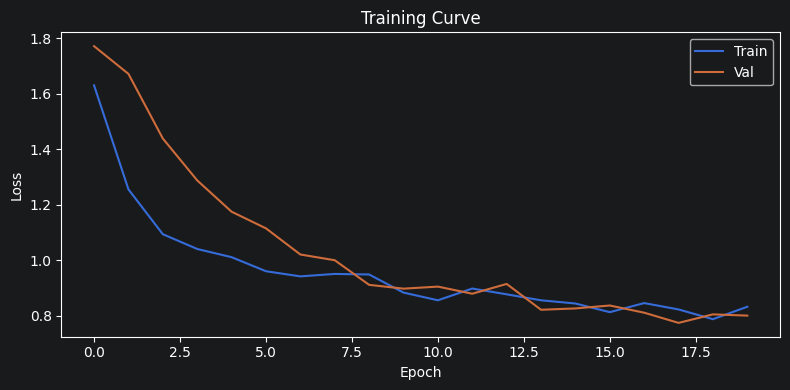

In [19]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training Curve")
plt.tight_layout()
plt.show()

### 1.6 Filter Visualization

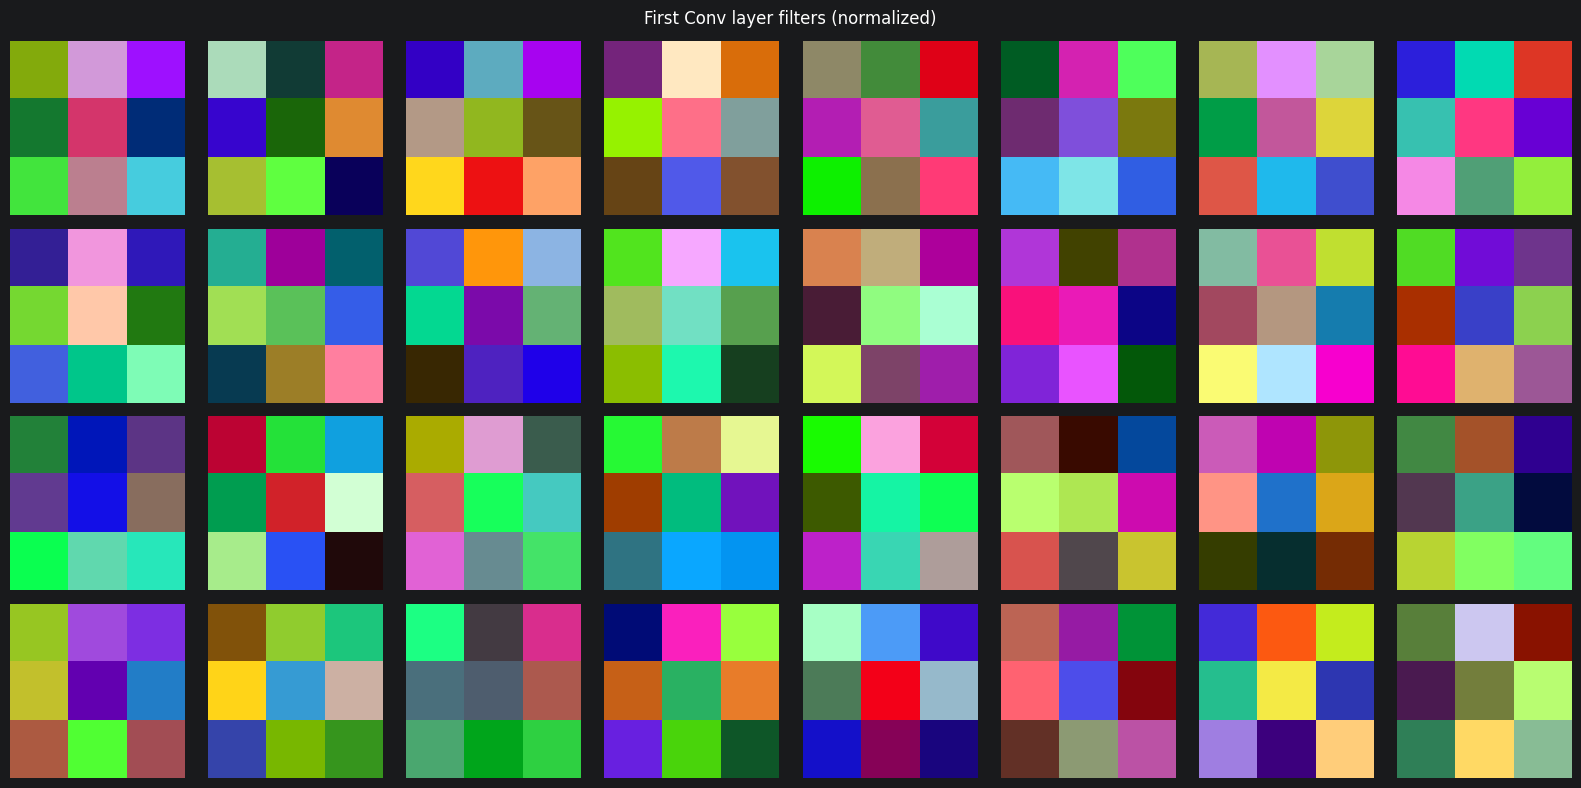

In [21]:
first_conv = model.encoders[0].net[0]  # first Conv2d layer
filters = first_conv.weight.data.cpu()  # [out_ch, in_ch, kH, kW]

n_filters = min(32, filters.shape[0])
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    if i < n_filters:
        f = filters[i]  # [3, 3, 3]
        # Normalize to [0, 1] for display
        f = (f - f.min()) / (f.max() - f.min() + 1e-8)
        ax.imshow(f.permute(1, 2, 0).numpy())
    ax.axis("off")
plt.suptitle("First Conv layer filters (normalized)")
plt.tight_layout()
plt.show()

**Do the filters seem to detect useful patterns or features?**

Tbh it is hard to tell. the colors look simmilar to the ones on the photos. but not the green one.

### 1.7 Evaluation

In [24]:
def compute_iou_per_class(model, loader, num_classes, device):
    model.eval()
    intersection = torch.zeros(num_classes)
    union = torch.zeros(num_classes)
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs).argmax(dim=1)  # [B, H, W]
            for c in range(num_classes):
                pred_c = preds == c
                true_c = masks == c
                intersection[c] += (pred_c & true_c).sum().item()
                union[c] += (pred_c | true_c).sum().item()
    iou = intersection / (union + 1e-8)
    return iou


iou_per_class = compute_iou_per_class(model, val_loader, NUM_CLASSES, DEVICE)
print("IoU per class:")
for i, cls in CLASSES.items():
    print(f"  {cls}: {iou_per_class[i]:.4f}")
print(f"\nMean IoU: {iou_per_class.mean():.4f}")

IoU per class:
  Building: 0.4993
  Land (unpaved area): 0.6772
  Road: 0.3782
  Vegetation: 0.5829
  Water: 0.8809
  Unlabeled: 0.0000

Mean IoU: 0.5031


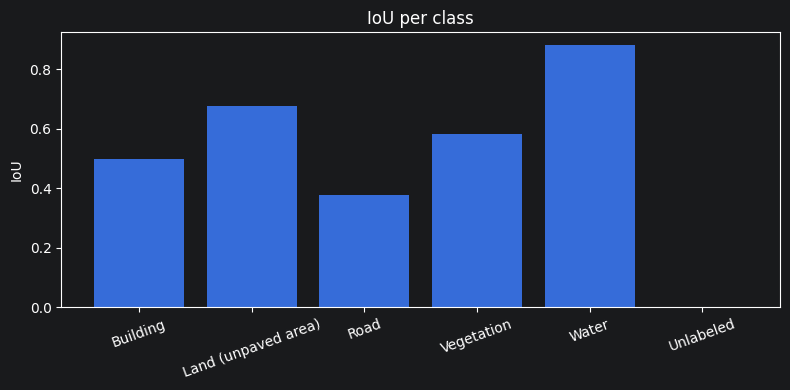

In [25]:
plt.figure(figsize=(8, 4))
plt.bar([CLASSES[i] for i in range(NUM_CLASSES)], iou_per_class.numpy())
plt.ylabel("IoU")
plt.title("IoU per class")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

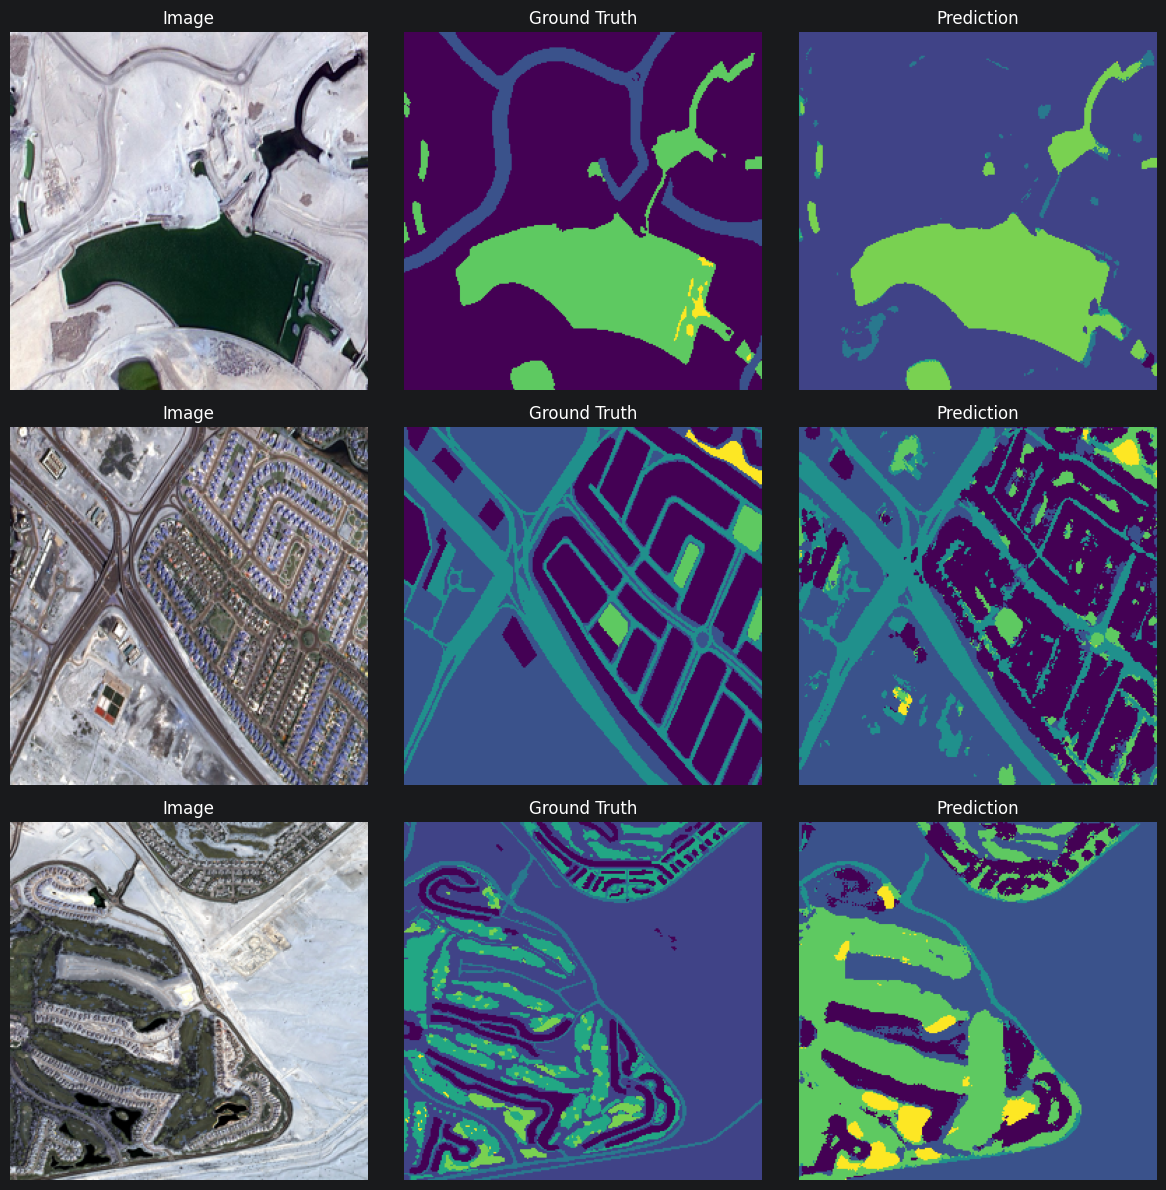

In [27]:
model.eval()
imgs_b, masks_b = next(iter(val_loader))
with torch.no_grad():
    preds_b = model(imgs_b.to(DEVICE)).argmax(dim=1).cpu()

n_show = 3
fig, axes = plt.subplots(n_show, 3, figsize=(12, 4 * n_show))
for i in range(n_show):
    axes[i, 0].imshow(imgs_b[i].permute(1, 2, 0).numpy())
    axes[i, 0].set_title("Image")
    axes[i, 0].axis("off")
    axes[i, 1].imshow(masks_b[i].numpy())
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")
    axes[i, 2].imshow(preds_b[i].numpy())
    axes[i, 2].set_title("Prediction")
    axes[i, 2].axis("off")
plt.tight_layout()
plt.show()

**Does the model perform better on certain classes? Are there classes that are harder to predict?**

Yes, it seems that the model works best on water and the worst on land.

---
## Task 2 [4pkt]

Implement the **SeqScan** clustering algorithm based on the pseudocode on page 16 of the following paper:  
https://arxiv.org/pdf/1805.02102

Test your algorithm using one of the two options:
- Create a few small sample datasets manually (worth 1 point), or
- Generate your own synthetic dataset, similar to the example shown in Figure 12 of the paper (worth 2 points).

### 2.1 SeqScan Implementation

In [2]:
def euclidean_dist(p, q):
    return float(np.sqrt(sum((a - b) ** 2 for a, b in zip(p, q))))


def run_dbscan(points, eps, K, dist_fn):
    """
    Standard DBSCAN on a list of points.
    Returns a dict: {cluster_id -> [list of local indices in that cluster]}.
    Noise points (label -1) are not included.
    """
    n = len(points)
    labels = [-1] * n

    def neighbors(i):
        return [j for j in range(n) if i != j and dist_fn(points[i], points[j]) <= eps]

    cluster_id = 0
    for i in range(n):
        if labels[i] != -1:
            continue  # already assigned
        nb = neighbors(i)
        if len(nb) < K - 1:
            continue  # not a core point → noise for now
        # Start a new cluster from core point i
        labels[i] = cluster_id
        stack = nb
        while stack:
            j = stack.pop()
            if labels[j] == -1:
                labels[j] = cluster_id
                nb_j = neighbors(j)
                if len(nb_j) >= K - 1:   # j is also a core point → expand further
                    stack.extend(nb_j)
        cluster_id += 1

    clusters = {}
    for i, lbl in enumerate(labels):
        if lbl >= 0:
            clusters.setdefault(lbl, []).append(i)
    return clusters


def seqscan(T, eps, K, delta, dist_fn=euclidean_dist):
    """
    SeqScan — Algorithm 1 from Damiani et al. (arXiv:1805.02102).

    Scans an ordered trajectory T and returns a list of stay regions.
    Each stay region is a list of indices (positions in T).

    Parameters
    ----------
    T     : ordered list of points (each point is a tuple of coordinates)
    eps   : spatial radius — how close points must be to be neighbours
    K     : minimum cluster size
    delta : minimum presence — how long (index span) a cluster must exist
              to qualify as a stay region
    """
    stay_regions = []

    # C = context: accumulates all points since the last stay region boundary.
    #   Used to test whether the new point can still extend the active stay region.
    # P = pool: points that failed to extend the active stay region.
    #   Searched for the next Minimal Stay Region (MSR).
    # Each entry is (original_index_in_T, point_coordinates).
    C = []
    P = []
    active_stay_indices = []   # original T-indices of the current active stay region

    for i, point in enumerate(T):

        # --- Step 1: always insert the new point into the context C ---
        C.append((i, point))

        # --- Step 2: canExpand? ---
        # Check whether point i is in the same DBSCAN cluster as the active
        # stay region when we cluster the full context C.
        active_set = set(active_stay_indices)
        c_points = [p for _, p in C]
        c_clusters = run_dbscan(c_points, eps, K, dist_fn)

        # Find which cluster (if any) contains both a member of the active stay
        # region AND the newly added point i (last element of C)
        point_is_connected_to_active_stay = any(
            any(C[m][0] in active_set for m in members)   # cluster touches active stay
            and C[-1][0] in {C[m][0] for m in members}    # cluster also contains point i
            for members in c_clusters.values()
        )

        if active_stay_indices and point_is_connected_to_active_stay:
            # i can be added to the active stay region → extend it and reset pool
            active_stay_indices.append(i)
            P = []

        else:
            # --- Step 3: i cannot extend the active stay region → add to pool ---
            P.append((i, point))

            # Check if pool now contains a new Minimal Stay Region
            p_points = [p for _, p in P]
            p_clusters = run_dbscan(p_points, eps, K, dist_fn)

            # A valid MSR must have temporal span (last_index - first_index) >= delta
            msr_indices = None
            for members in p_clusters.values():
                orig_indices = [P[m][0] for m in members]
                presence = orig_indices[-1] - orig_indices[0]
                if presence >= delta:
                    msr_indices = orig_indices
                    break

            if msr_indices is not None:
                # Close the current active stay region and start a new one
                if active_stay_indices:
                    stay_regions.append(active_stay_indices)
                active_stay_indices = msr_indices
                C = list(P)   # pool becomes the new context
                P = []

    # Close the last active stay region if it exists
    if active_stay_indices:
        stay_regions.append(active_stay_indices)

    return stay_regions


def fT(T, eps, K, step, dist_fn=euclidean_dist):
    """
    Algorithm 2 from the paper.

    Runs SeqScan repeatedly with increasing delta to show how the number
    of stay regions changes with the minimum presence threshold.

    Returns SetOfPairs: list of ((delta, min_presence), num_stay_regions)
    """
    set_of_pairs = []
    delta = 0

    while True:
        S = seqscan(T, eps, K, delta, dist_fn)

        if not S:
            break  # no more stay regions found → stop

        # minimum presence = smallest temporal span across all stay regions
        min_presence = min(indices[-1] - indices[0] for indices in S)
        set_of_pairs.append(((delta, min_presence), len(S)))

        # next iteration starts just after the minimum presence value
        delta = min_presence + step

    return set_of_pairs


# ── Sanity check ──────────────────────────────────────────────────────────────
toy = [(0,), (0.1,), (0.2,), (5.0,), (5.1,), (5.2,), (10.0,)]
stays = seqscan(toy, eps=0.5, K=2, delta=0)
print("SeqScan stay regions (index groups):", stays)
# Expected: two clusters → [[0,1,2], [3,4,5]], point 6 is noise

pairs = fT(toy, eps=0.5, K=2, step=0.5)
print("fT SetOfPairs:", pairs)

SeqScan stay regions: [[0, 1, 2], [3, 4, 5]]
fT SetOfPairs: [((0, 2), 2)]


### 2.2 Test on Synthetic Dataset

Found 4 clusters
fT SetOfPairs: [((0, 29), 4), ((30, 95), 1)]


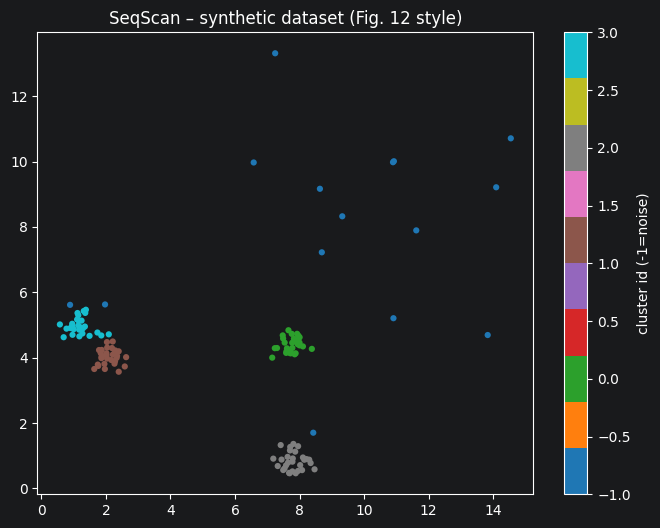

In [4]:
rng = np.random.default_rng(42)

def make_synthetic_sequence(n_clusters=4, cluster_size=30, noise_frac=0.1, spread=0.3, gap=3.0):
    points = []
    t = 0.0
    for _ in range(n_clusters):
        center = rng.uniform(0, 10, size=2)
        cluster_pts = center + rng.normal(0, spread, size=(cluster_size, 2))
        # order within cluster by arc-length approximation
        order = np.argsort(cluster_pts[:, 0])
        points.extend(cluster_pts[order].tolist())
        # add gap (noise) between clusters
        n_noise = int(cluster_size * noise_frac)
        noise_pts = center + rng.uniform(gap, gap * 3, size=(n_noise, 2))
        points.extend(noise_pts.tolist())
    return [tuple(p) for p in points]


synth_seq = make_synthetic_sequence()
clusters_synth = seqscan(synth_seq, eps=0.5, K=5, delta=0)

labels_synth = [-1] * len(synth_seq)
for cid, cluster in enumerate(clusters_synth):
    for idx in cluster:
        labels_synth[idx] = cid

print(f"Found {len(clusters_synth)} clusters")
pairs_synth = fT(synth_seq, eps=0.5, K=5, step=1)
print("fT SetOfPairs:", pairs_synth)

xs, ys = zip(*synth_seq)
plt.figure(figsize=(8, 6))
plt.scatter(xs, ys, c=labels_synth, cmap="tab10", s=20, edgecolors="none", vmin=-1)
plt.title("SeqScan – synthetic dataset (Fig. 12 style)")
plt.colorbar(label="cluster id (-1=noise)")
plt.show()

---
## Task 3 [3pkt]

**a)** [0.5 points] What is the time complexity of the approximate algorithm used for trajectory partitioning in the TRACLUS algorithm? Provide a justification for your answer.

**b)** [0.5 points] Give an example where the approximate algorithm for trajectory partitioning fails to find the optimal partitioning.

**c)** [1 point] Let's consider hurricane trajectories. Intuitively, stronger hurricanes should have higher weights when calculating the loss function \(N_\varepsilon\). How could you modify a density-based clustering algorithm for line segmentation to take trajectory weights into account?

**d)** [1 point] Is the original distance function used in density-based clustering for line segmentation a proper metric? Use the triangle inequality to provide a counterexample if it is not.

### 3a) Time Complexity of Approximate Trajectory Partitioning

Because all we do is go through all the points with greedy approach, it is linear O(n)

### 3b) Failure Case of Approximate Partitioning
```
            o

o   o   o       o     o     o

           /\
          /  \
---------/    \--------------
```

In this case o are points. In the broad view the outlier should be neglected, but greedy algorithm would think it is worth to add new lines.

### 3c) Weighting Hurricanes in Density-Based Clustering

Normally traculus works like that: when they are at least X lines then group them. Easiest thing to modify here would be to give every line a weight and then instead of counting lines we would sum weights.

### 3d) Triangle Inequality Counterexample


TRACALUS counts distance as sum of parallel distance, perpendicular distance(prostopadla) and angle distance.

Lets imagine A - short beginning, B - whole road, C - short ending and perpendicular and angle distance between them is 0. We only consider parallel distance.

A and B align perfectly so distance is 0.

B and C align perfectly so distance is 0.

So using triangle inequality if A-B + B-C = 0 => A-C = 0

But there is a gap between A and C so it is not equal to 0.